In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split , KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix , ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

# Classifying images of numbers using support vector machines and logistic regression

### Part A: Data Preprocessing

In [ ]:
# part 1 & 4
data=load_digits()
print(type(data))

# because we use data.data we receive the flattened shape of images
X=data.data
print(type(X))
y=data.target
print(type(y))

<class 'sklearn.utils._bunch.Bunch'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
# part 2
print('number of classes is: ',len(np.unique(y)))
print('shape of X is: ',X.shape)
print('shape of y is: ',y.shape)

number of classes is:  10
shape of X is:  (1797, 64)
shape of y is:  (1797,)


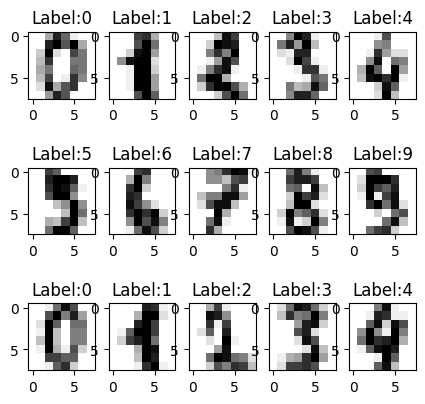

In [ ]:
# part 3
fig,axes=plt.subplots(3,5,figsize=(5,5))
for i ,ax in enumerate(axes.flat):
  ax.imshow(data.images[i],cmap='binary')
  ax.set_title(f'Label:{data.target[i]}')
plt.show()

In [ ]:
# part 5
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=67)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1437, 64)
(360, 64)
(1437,)
(360,)


### Part B: SVM

In [ ]:
# part 1
model1=SVC(kernel='linear')
model1.fit(X_train,y_train)

model2=SVC(kernel='rbf')
model2.fit(X_train,y_train)

model3=SVC(kernel='sigmoid')
model3.fit(X_train,y_train)

SVC(kernel='sigmoid')

In [ ]:
# part 2
y_pred1=model1.predict(X_test)
y_pred2=model2.predict(X_test)
y_pred3=model3.predict(X_test)

# accuracy
print('accuracy of linear model is: ',accuracy_score(y_test,y_pred1))
print('accuracy of rbf model is: ',accuracy_score(y_test,y_pred2))
print('accuracy of sigmoid model is: ',accuracy_score(y_test,y_pred3))

# precision
print('precision of linear model is: ',precision_score(y_test,y_pred1,average='macro'))
print('precision of rbf model is: ',precision_score(y_test,y_pred2,average='macro'))
print('precision of sigmoid model is: ',precision_score(y_test,y_pred3,average='macro'))

# recall
print('recall of linear model is: ',recall_score(y_test,y_pred1,average='macro'))
print('recall of rbf model is: ',recall_score(y_test,y_pred2,average='macro'))
print('recall of sigmoid model is: ',recall_score(y_test,y_pred3,average='macro'))

# F1-score
print('F1-score of linear model is: ',f1_score(y_test,y_pred1,average='macro'))
print('F1-score of rbf model is: ',f1_score(y_test,y_pred2,average='macro'))
print('F1-score of sigmoid model is: ',f1_score(y_test,y_pred3,average='macro'))


accuracy of linear model is:  0.975
accuracy of rbf model is:  0.9861111111111112
accuracy of sigmoid model is:  0.9055555555555556
precision of linear model is:  0.974148388743977
precision of rbf model is:  0.985723642905438
precision of sigmoid model is:  0.9101175001230619
recall of linear model is:  0.9733937728690354
recall of rbf model is:  0.9862342638204706
recall of sigmoid model is:  0.9100335263306197
F1-score of linear model is:  0.9735277566800024
F1-score of rbf model is:  0.9858528376181489
F1-score of sigmoid model is:  0.9082661156376105


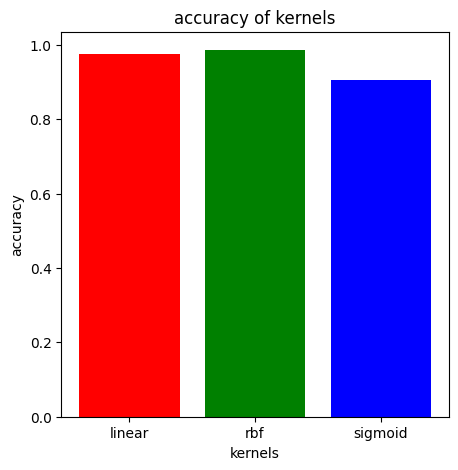

In [ ]:
# part 3
kernels=['linear','rbf','sigmoid']
accuracies=[accuracy_score(y_test,y_pred1),accuracy_score(y_test,y_pred2),accuracy_score(y_test,y_pred3)]

plt.figure(figsize=(5,5))
plt.bar(kernels,accuracies,color=['red','green','blue'])
plt.xlabel('kernels')
plt.ylabel('accuracy')
plt.title('accuracy of kernels')
plt.show()

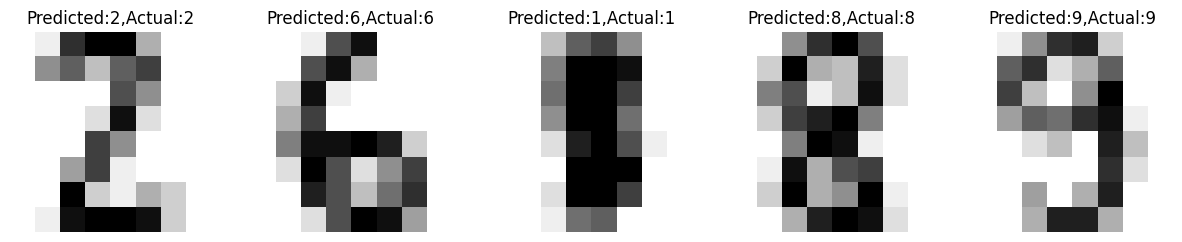

In [ ]:
# part 4   best model = rbf kernel
indices=np.random.choice(X_test.shape[0],5,replace=False)
plt.figure(figsize=(15,5))
for i,index in enumerate(indices):
  plt.subplot(1,5,i+1)
  plt.imshow(X_test[index].reshape(8,8),cmap='binary')
  plt.title(f'Predicted:{y_pred2[index]},Actual:{y_test[index]}')
  plt.axis('off')
plt.show()


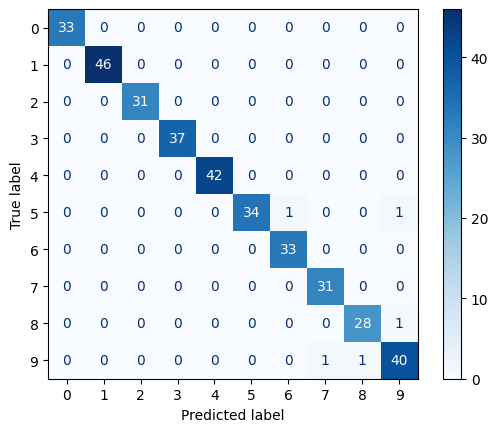

In [ ]:
# part 5    confusion matrix of SVM with rbf kernel = best model
temp=confusion_matrix(y_test,y_pred2)
display=ConfusionMatrixDisplay(confusion_matrix=temp,display_labels=data.target_names)
display.plot(cmap='Blues')
plt.show()

### Part C: Model Performance Review for Logistic Regression

In logistic regression with the softmax function, the model labels must be in the form of one-hot vectors, and for each class we have a weight vector that has the same number of features as the model. We also have a bias for each class. To update the weights, the gradients of the cross-entropy function and the decreasing gradient are used.

In [29]:
# part 1
class softmaxRegression:

  def __init__(self,learning_rate=0.1,num_epochs=100):
    self.lr=learning_rate
    self.num_epoch=num_epochs
    self.weights=0
    self.bias=0

  def softmax_fn(self,x):
    return np.exp(x)/np.sum(np.exp(x),axis=1,keepdims=True)

  def train(self,X,y):
    num_samples,num_features=X.shape
    num_classes=len(np.unique(y))

    self.weights=np.random.rand(num_features,num_classes)
    self.bias=np.random.rand(num_classes)

    temp=pd.Series(y)
    temp=pd.get_dummies(temp)
    y=temp.values

    for epoch in range(self.num_epoch):
      z=np.dot(X,self.weights)+self.bias
      y_pred=self.softmax_fn(z)

      self.weights-=self.lr*(np.dot(X.T,(y_pred-y)))/num_samples
      self.bias-=self.lr*(np.sum(y_pred-y))/num_samples

  def predict(self,X):
    z=np.dot(X,self.weights)+self.bias
    y_pred=self.softmax_fn(z)
    return np.argmax(y_pred,axis=1)


model=softmaxRegression(learning_rate=0.1,num_epochs=250)
model.train(X_train,y_train)



In [30]:
# part 2
y_pred=model.predict(X_test)

# accuracy
print('accuracy of softmax regression is: ',accuracy_score(y_test,y_pred))

# precision
print('precision of softmax regression is: ',precision_score(y_test,y_pred,average='macro'))

# recall
print('recall of softmax regression is: ',recall_score(y_test,y_pred,average='macro'))

# F1-score
print('F1-score of softmax regression is: ',f1_score(y_test,y_pred,average='macro'))


accuracy of softmax regression is:  0.9277777777777778
precision of softmax regression is:  0.9256657897506051
recall of softmax regression is:  0.9289649094371732
F1-score of softmax regression is:  0.9254112934078366


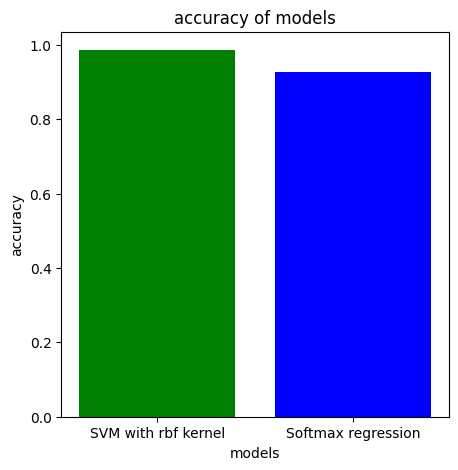

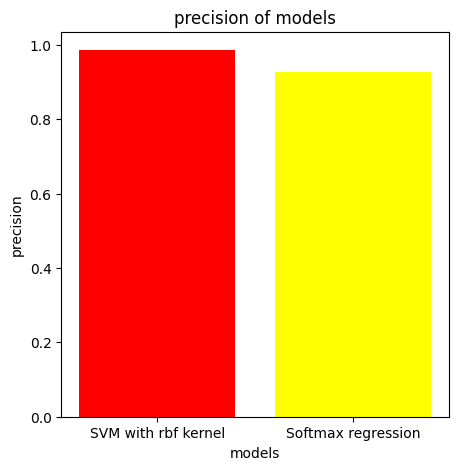

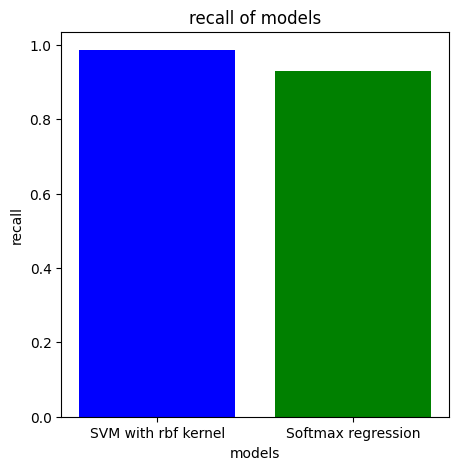

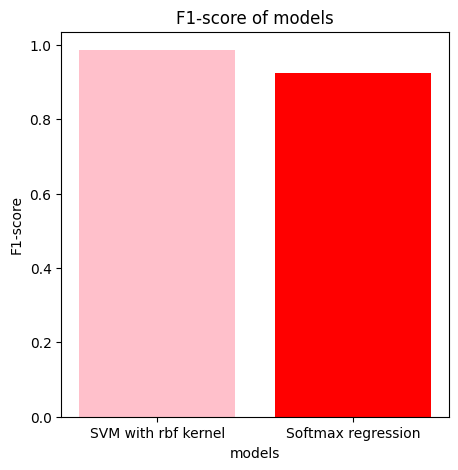

In [34]:
# part 3
models=['SVM with rbf kernel','Softmax regression']
accuracies=[accuracy_score(y_test,y_pred2),accuracy_score(y_test,y_pred)]
precisions=[precision_score(y_test,y_pred2,average='macro'),precision_score(y_test,y_pred,average='macro')]
recalls=[recall_score(y_test,y_pred2,average='macro'),recall_score(y_test,y_pred,average='macro')]
f1_scores=[f1_score(y_test,y_pred2,average='macro'),f1_score(y_test,y_pred,average='macro')]

plt.figure(figsize=(5,5))
plt.bar(models,accuracies,color=['green','blue'])
plt.xlabel('models')
plt.ylabel('accuracy')
plt.title('accuracy of models')
plt.show()

plt.figure(figsize=(5,5))
plt.bar(models,precisions,color=['red','yellow'])
plt.xlabel('models')
plt.ylabel('precision')
plt.title('precision of models')
plt.show()

plt.figure(figsize=(5,5))
plt.bar(models,recalls,color=['blue','green'])
plt.xlabel('models')
plt.ylabel('recall')
plt.title('recall of models')
plt.show()

plt.figure(figsize=(5,5))
plt.bar(models,f1_scores,color=['pink','red'])
plt.xlabel('models')
plt.ylabel('F1-score')
plt.title('F1-score of models')
plt.show()

In all metrics, the support vector machine model with Gaussian kernel was better. The accuracy of the softmax model was about the same as the support vector machine model with sigmoid kernel.

Confusion matrix of SVM with rbf kernel: 


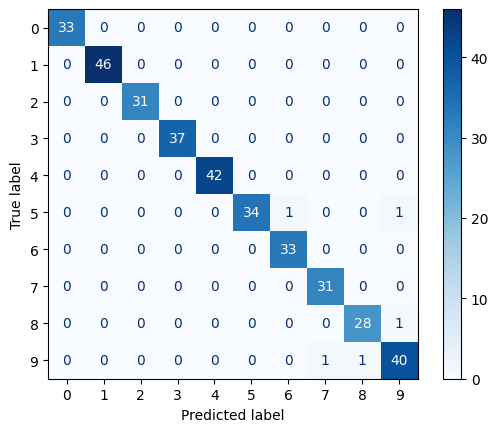


Confusion matrix of softmax regression: 


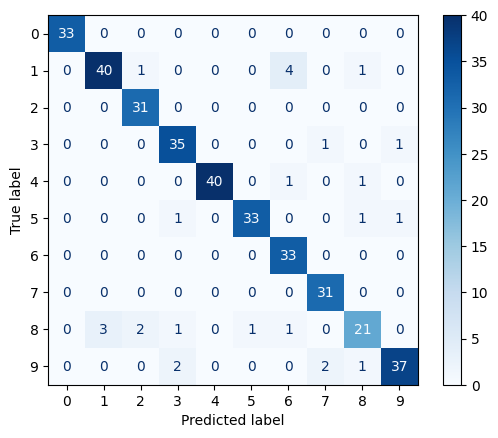

In [36]:
# part 4
print('Confusion matrix of SVM with rbf kernel: ')
temp1=confusion_matrix(y_test,y_pred2)
display=ConfusionMatrixDisplay(confusion_matrix=temp1,display_labels=data.target_names)
display.plot(cmap='Blues')
plt.show()


print('\nConfusion matrix of softmax regression: ')
temp2=confusion_matrix(y_test,y_pred)
display=ConfusionMatrixDisplay(confusion_matrix=temp2,display_labels=data.target_names)
display.plot(cmap='Blues')
plt.show()


Due to the above confusion matrices, the SoftMax model had many more errors. For example, the data labeled 8, which the support vector machine model only mistook for the number 9, was mistaken for the SoftMax model with the numbers 1, 2, 3, 5, and 6. Also, many examples in other classes were predicted incorrectly. For example, according to the table, it is clear that the SoftMax model recognized classes 3 and 9 or classes 1 and 8 interchangeably, but the Support Vector Machine model recognized classes 8 and 9 interchangeably.

In [41]:
# part 5
kf=KFold(n_splits=5,shuffle=True)
accuracies=[]

scaler=StandardScaler()
X_=scaler.fit_transform(X)

for train_idx,test_idx in kf.split(X_):
  X_train_temp,X_test_temp=X_[train_idx],X_[test_idx]
  y_train_temp,y_test_temp=y[train_idx],y[test_idx]

  model.train(X_train_temp,y_train_temp)
  y_pred_temp=model.predict(X_test_temp)
  accuracies.append(accuracy_score(y_test_temp,y_pred_temp))


print('accuracy in each fold:')
for i , acc in enumerate(accuracies):
  print(f'fold {i+1}: {acc}')

print('average accuracy: ',np.mean(accuracies))
print('std of accuracies: ',np.std(accuracies))

accuracy in each fold:
fold 1: 0.9305555555555556
fold 2: 0.9222222222222223
fold 3: 0.9387186629526463
fold 4: 0.9415041782729805
fold 5: 0.9387186629526463
average accuracy:  0.9343438563912102
std of accuracies:  0.007082842826135899
